In [ ]:
import pandas as pd
import os
import shutil

# ==========================================
# 1. 경로 설정 (이 부분만 수정하세요)
# ==========================================
xls_PATH = '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/core_v1_3_1088/core_v1_3_1088_sorted.xlsx'
IMAGE_SOURCE_DIR = '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/core_v1_3_1088'      # 원본 이미지들이 있는 폴더
TARGET_BASE_DIR = '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/Practice 2_지표추출개선test/lettuce'   # 결과물을 저장할 폴더

# ==========================================
# 2. 데이터 분석 및 추출 함수
# ==========================================

def extract_golden_data():
    # 데이터 로드
    df = pd.read_excel(xls_PATH)

    # [필터링 1] core_strength가 2인 행 추출
    seeds = df[df['core_strength'] == 2].copy()

    # 베드명과 상추ID(b3 등) 추출 (파일명 규칙 기반)
    # 예: bed00_20251214_..._b3_... -> bed00, b3
    def parse_id(img_id):
        parts = img_id.split('_')
        return parts[0], parts[4] # bedXX, bX

    seeds['bed_id'], seeds['lettuce_id'] = zip(*seeds['image_id'].map(parse_id))

    # [필터링 2] 선발된 상추(bed+id 조합)의 모든 날짜 데이터 가져오기
    # 중복 제거를 위해 고유한 (bed, lettuce_id) 쌍 확보
    unique_plants = seeds[['bed_id', 'lettuce_id']].drop_duplicates()

    final_list = []
    for _, row in unique_plants.iterrows():
        # 전체 데이터에서 해당 베드와 상추ID가 포함된 모든 행 찾기
        mask = (df['image_id'].str.contains(row['bed_id'])) & (df['image_id'].str.contains(row['lettuce_id']))
        plant_history = df[mask]
        final_list.append(plant_history)

    golden_df = pd.concat(final_list).drop_duplicates(subset=['image_id'])

    # 결과 폴더 생성
    os.makedirs(TARGET_BASE_DIR, exist_ok=True)
    os.makedirs(os.path.join(TARGET_BASE_DIR, '2'), exist_ok=True)

    # [파일 복사]
    print(f"추출된 전체 이미지: {len(golden_df)}개")
    print(f"그 중 core_strength=2 인 이미지: {len(seeds)}개")

    for _, row in golden_df.iterrows():
        img_name = row['image_id'] + ".png" # 확장자 확인 필요
        src_path = os.path.join(IMAGE_SOURCE_DIR, img_name)

        if os.path.exists(src_path):
            # core_strength가 2인 경우 '2' 폴더로, 아니면 상위 폴더로
            if row['core_strength'] == 2:
                dst_path = os.path.join(TARGET_BASE_DIR, '2', img_name)
            else:
                dst_path = os.path.join(TARGET_BASE_DIR, img_name)

            shutil.copy(src_path, dst_path)

    # 추출 리스트도 CSV로 저장
    golden_df.to_excel('golden_data_list.xlsx', index=False)
    print("작업 완료! 'golden_dataset' 폴더를 확인하세요.")

if __name__ == "__main__":
    extract_golden_data()

추출된 전체 이미지: 305개
그 중 core_strength=2 인 이미지: 122개
작업 완료! 'golden_dataset' 폴더를 확인하세요.


In [ ]:
import os

# ==========================================
# 1. 경로 설정 (이 부분만 확인하세요)
# ==========================================
SUB_DIR_NAME = '2'                             # 선별된 70개가 들어있는 폴더명
SUB_DIR_PATH = os.path.join(TARGET_BASE_DIR, SUB_DIR_NAME)

def sync_and_cleanup():
    # 2. '2' 폴더를 탐색하여 살아남은 '베드+상추' 명단 확보
    allowed_plants = set()

    if not os.path.exists(SUB_DIR_PATH):
        print(f"오류: {SUB_DIR_PATH} 폴더를 찾을 수 없습니다.")
        return

    print(f"'{SUB_DIR_NAME}' 폴더 기반으로 필터링 리스트를 생성합니다...")

    for filename in os.listdir(SUB_DIR_PATH):
        # 이미지 파일만 대상 (png, jpg 등)
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            parts = filename.split('_')
            if len(parts) > 4:
                # 파일명 규칙: bedXX_날짜_시간_카메라_상추ID_...
                bed_id = parts[0]     # 예: bed00
                lettuce_id = parts[4] # 예: b3
                allowed_plants.add((bed_id, lettuce_id))

    print(f"선발된 골든 상추 개체 수: {len(allowed_plants)}개")

    # 3. 메인 폴더(TARGET_BASE_DIR)에서 명단에 없는 파일 삭제
    delete_count = 0
    keep_count = 0

    # 메인 폴더 내의 파일들만 탐색 (하위 폴더는 제외)
    for filename in os.listdir(TARGET_BASE_DIR):
        full_path = os.path.join(TARGET_BASE_DIR, filename)

        # 폴더('2' 폴더 등)는 건드리지 않고 파일만 처리
        if os.path.isfile(full_path):
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                parts = filename.split('_')
                if len(parts) > 4:
                    bed_id = parts[0]
                    lettuce_id = parts[4]

                    # 선발된 명단(베드, 상추ID)에 있는지 확인
                    if (bed_id, lettuce_id) in allowed_plants:
                        keep_count += 1
                    else:
                        # 명단에 없으면 삭제
                        os.remove(full_path)
                        delete_count += 1

    print("-" * 30)
    print(f"작업 완료!")
    print(f"유지된 골든 데이터(시계열 포함): {keep_count}개")
    print(f"삭제된 일반 데이터: {delete_count}개")
    print(f"하위 폴더 '{SUB_DIR_NAME}'은 원본 그대로 유지되었습니다.")

if __name__ == "__main__":
    sync_and_cleanup()

'2' 폴더 기반으로 필터링 리스트를 생성합니다...
선발된 골든 상추 개체 수: 63개
------------------------------
작업 완료!
유지된 골든 데이터(시계열 포함): 96개
삭제된 일반 데이터: 87개
하위 폴더 '2'은 원본 그대로 유지되었습니다.


#Step 1: Orientation Map (보라) 시각화 코드

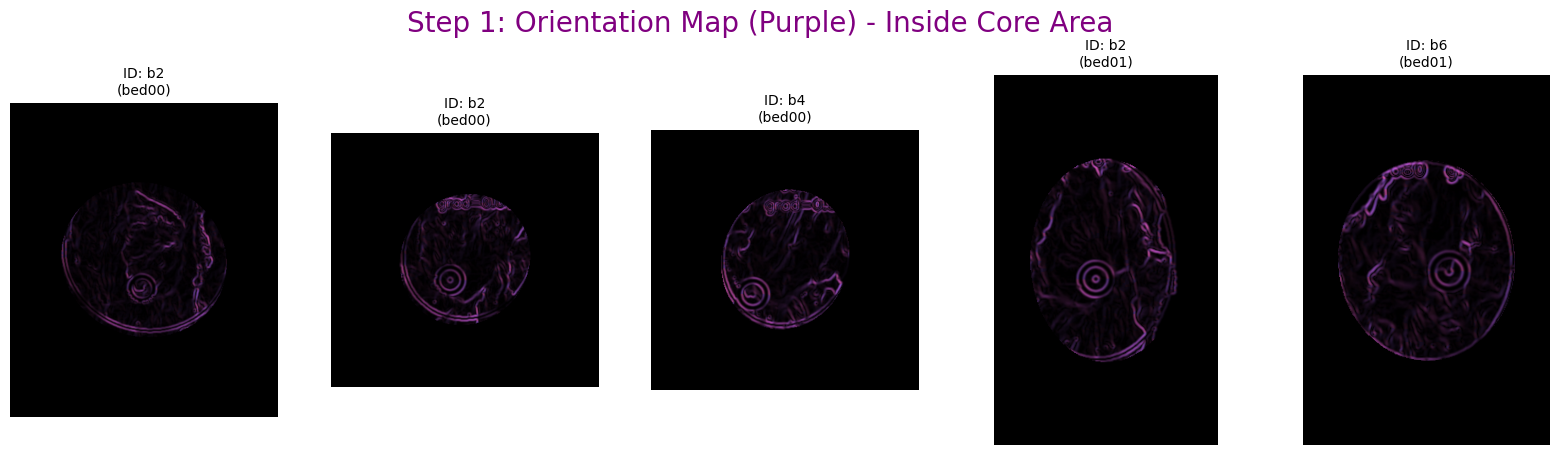

시각화 완료! 결과가 /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/Practice 2_지표추출개선test/step1_orientation_report.png에 저장되었습니다.


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. 경로 설정 (사용자 환경에 맞게 수정)
# ==========================================
IMAGE_DIR = '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/Practice 2_지표추출개선test/lettuce/2'           # 골든 데이터(2번 폴더) 경로
xls_PATH = '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/core_v1_3_1088/core_v1_3_1088_sorted.xlsx'
OUTPUT_PATH = '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/Practice 2_지표추출개선test/step1_orientation_report.png'

# ==========================================
# 2. 이미지 및 데이터 추출 함수
# ==========================================

def get_orientation_map(image, ellipse_params):
    """이미지의 기울기(Orientation)를 계산하고 보라색 테마로 변환"""
    # 그레이스케일 변환 및 가우시안 블러 (노이즈 제거)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Sobel 필터를 이용한 X, Y 기울기 계산
    gx = cv2.Sobel(blurred, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(blurred, cv2.CV_32F, 0, 1, ksize=3)

    # 각도(Angle) 계산 (0 ~ 180도)
    mag, ang = cv2.cartToPolar(gx, gy, angleInDegrees=True)
    ang = ang % 180  # 방향성만 보기 위해 180도로 정규화

    # 타원 마스크 생성
    mask = np.zeros_like(gray)
    cx, cy = int(ellipse_params['center_x']), int(ellipse_params['center_y'])
    ma, mi = int(ellipse_params['axis_major'] / 2), int(ellipse_params['axis_minor'] / 2)
    angle = ellipse_params['angle_deg']
    cv2.ellipse(mask, (cx, cy), (ma, mi), angle, 0, 360, 255, -1)

    # 보라색 테마 적용 (HSV 활용)
    # Purple의 Hue 값은 대략 130~160 (OpenCV 기준 255 만점 시)
    hsv = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.uint8)
    hsv[..., 0] = 135 + (ang / 180.0 * 25.0)  # 보라색 범위 내에서 각도에 따라 변화
    hsv[..., 1] = 150                         # 채도 고정
    hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX) # 밝기를 기울기 세기로

    orientation_img = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

    # 마스크 적용 (타원 안만 남기기)
    result = cv2.bitwise_and(orientation_img, orientation_img, mask=mask)
    return result

# ==========================================
# 3. 메인 시각화 실행
# ==========================================

def run_step1_visualization():
    # 데이터 로드
    df = pd.read_excel(xls_PATH)

    # '2' 폴더 내 파일 리스트 (이름순 5개)
    file_list = sorted([f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(('.png', '.jpg'))])
    target_files = file_list[:5]

    fig, axes = plt.subplots(1, 5, figsize=(20, 5))
    plt.subplots_adjust(top=0.85)
    fig.suptitle('Step 1: Orientation Map (Purple) - Inside Core Area', fontsize=20, color='purple')

    for i, fname in enumerate(target_files):
        img_id = os.path.splitext(fname)[0]
        img_path = os.path.join(IMAGE_DIR, fname)

        # 이미지 읽기
        img = cv2.imread(img_path)
        if img is None: continue

        # CSV에서 해당 이미지의 타원 파라미터 가져오기
        row = df[df['image_id'] == img_id].iloc[0]

        # Orientation Map 생성
        ori_map = get_orientation_map(img, row)

        # 시각화
        axes[i].imshow(cv2.cvtColor(ori_map, cv2.COLOR_BGR2RGB))
        axes[i].set_title(f"ID: {row['image_id'].split('_')[4]}\n({row['image_id'].split('_')[0]})", fontsize=10)
        axes[i].axis('off')

    plt.savefig(OUTPUT_PATH)
    plt.show()
    print(f"시각화 완료! 결과가 {OUTPUT_PATH}에 저장되었습니다.")

if __name__ == "__main__":
    run_step1_visualization()

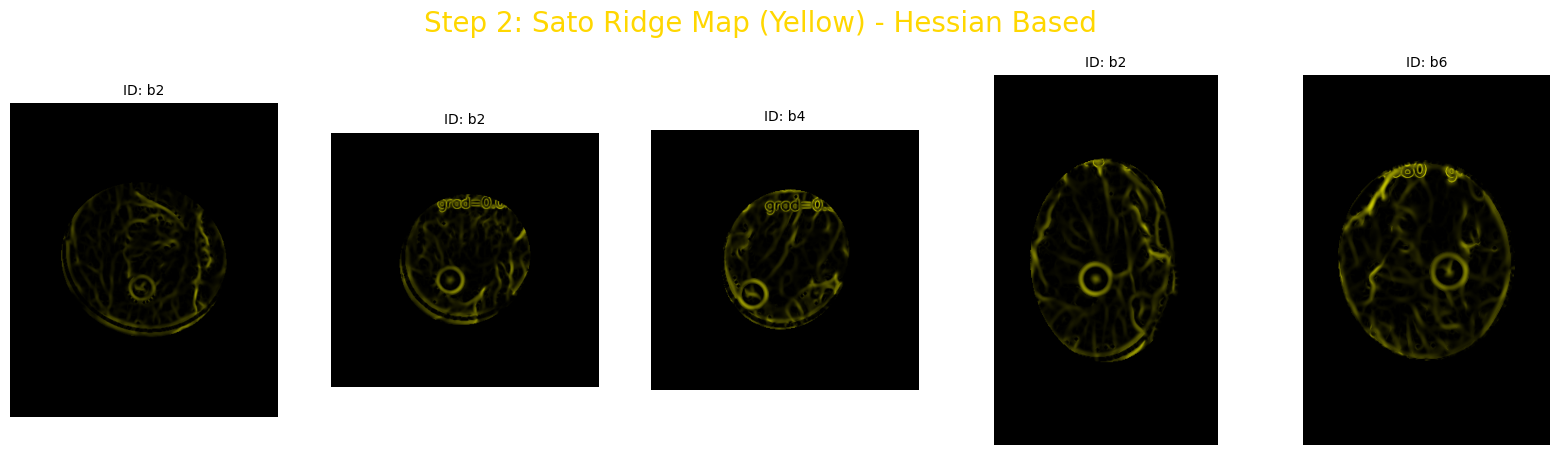

Step 2 완료! 결과가 /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/Practice 2_지표추출개선test/step2_ridge_sato_report.png에 저장되었습니다.


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.filters import sato  # Hessian 기반 Ridge 검출기

# ==========================================
# 1. 경로 설정 (기존과 동일)
# ==========================================
IMAGE_DIR = '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/Practice 2_지표추출개선test/lettuce/2'           # 골든 데이터(2번 폴더) 경로
xls_PATH = '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/core_v1_3_1088/core_v1_3_1088_sorted.xlsx'
OUTPUT_PATH = '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/Practice 2_지표추출개선test/step2_ridge_sato_report.png'

# ==========================================
# 2. Sato Ridge Map 생성 함수
# ==========================================

def get_sato_ridge_map(image, ellipse_params):
    """Sato 필터를 적용하여 잎의 경계를 노란색 음영으로 추출"""
    # 1. 전처리 (그레이스케일)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # 2. Sato 필터 적용 (Hessian Matrix 기반)
    # sigmas는 탐지할 선의 굵기 범위를 뜻함 (양상추 잎 경계에 맞춰 1~3 정도가 적당)
    ridge = sato(gray, sigmas=range(1, 4), black_ridges=False)

    # 3. 결과 정규화 (0~255)
    ridge_norm = cv2.normalize(ridge, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # 4. 노란색 테마 입히기
    # Ridge 강도를 밝기(V)로 사용하고, 색상(H)을 노란색(약 30)으로 고정
    hsv = np.zeros((image.shape[0], image.shape[1], 3), dtype=np.uint8)
    hsv[..., 0] = 30           # Yellow Hue
    hsv[..., 1] = 255          # Saturation Max
    hsv[..., 2] = ridge_norm   # 밝기를 Ridge 강도로

    ridge_yellow = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

    # 5. 타원 마스크 생성 및 적용
    mask = np.zeros_like(gray)
    cx, cy = int(ellipse_params['center_x']), int(ellipse_params['center_y'])
    ma, mi = int(ellipse_params['axis_major'] / 2), int(ellipse_params['axis_minor'] / 2)
    angle = ellipse_params['angle_deg']
    cv2.ellipse(mask, (cx, cy), (ma, mi), angle, 0, 360, 255, -1)

    result = cv2.bitwise_and(ridge_yellow, ridge_yellow, mask=mask)
    return result

# ==========================================
# 3. 메인 시각화 실행
# ==========================================

def run_step2_visualization():
    df = pd.read_excel(xls_PATH)
    file_list = sorted([f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(('.png', '.jpg'))])
    target_files = file_list[:5]

    fig, axes = plt.subplots(1, 5, figsize=(20, 5))
    plt.subplots_adjust(top=0.85)
    fig.suptitle('Step 2: Sato Ridge Map (Yellow) - Hessian Based', fontsize=20, color='#FFD700')

    for i, fname in enumerate(target_files):
        img_id = os.path.splitext(fname)[0]
        img_path = os.path.join(IMAGE_DIR, fname)

        img = cv2.imread(img_path)
        if img is None: continue

        # CSV에서 타원 파라미터 매칭
        row = df[df['image_id'] == img_id].iloc[0]

        # Sato Ridge Map 생성
        ridge_map = get_sato_ridge_map(img, row)

        # 출력
        axes[i].imshow(cv2.cvtColor(ridge_map, cv2.COLOR_BGR2RGB))
        axes[i].set_title(f"ID: {row['image_id'].split('_')[4]}", fontsize=10)
        axes[i].axis('off')

    plt.savefig(OUTPUT_PATH)
    plt.show()
    print(f"Step 2 완료! 결과가 {OUTPUT_PATH}에 저장되었습니다.")

if __name__ == "__main__":
    run_step2_visualization()

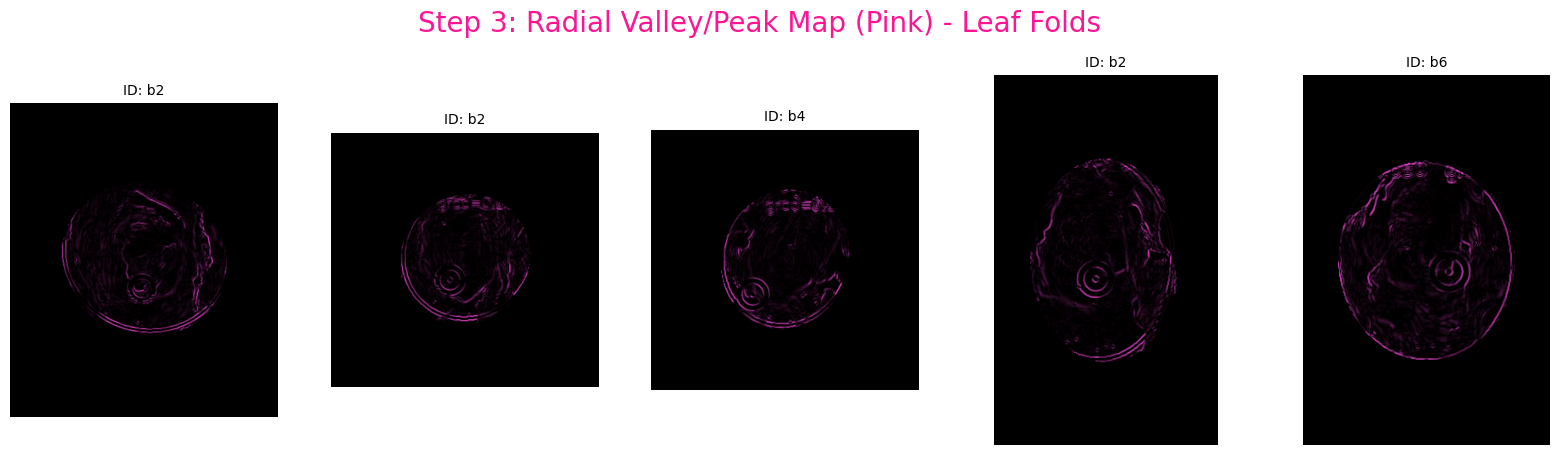

Step 3 완료! 결과가 /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/Practice 2_지표추출개선test/step3_radial_fold_report.png에 저장되었습니다.


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. 경로 설정
# ==========================================
IMAGE_DIR = '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/Practice 2_지표추출개선test/lettuce/2'           # 골든 데이터(2번 폴더) 경로
xls_PATH = '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/core_v1_3_1088/core_v1_3_1088_sorted.xlsx'
OUTPUT_PATH = '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/Practice 2_지표추출개선test/step3_radial_fold_report.png'

# ==========================================
# 2. Radial Valley/Peak Map 생성 함수
# ==========================================

def get_radial_fold_map(image, ellipse_params):
    """중심으로부터의 방사형 밝기 변화(Folds)를 분홍색으로 추출"""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.equalizeHist(gray) # 대비 강화

    h, w = gray.shape
    cx, cy = int(ellipse_params['center_x']), int(ellipse_params['center_y'])

    # 1. 거리 맵 생성 (중심으로부터 각 픽셀까지의 거리)
    y, x = np.ogrid[:h, :w]
    dist_from_center = np.sqrt((x - cx)**2 + (y - cy)**2)

    # 2. 방사형 그래디언트 (Radial Gradient) 계산
    # 소벨 필터와 거리 맵의 방향을 결합하여 '바깥쪽으로의 변화량' 산출
    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)

    # 각 픽셀에서의 방사 방향 벡터
    rx = (x - cx) / (dist_from_center + 1e-5)
    ry = (y - cy) / (dist_from_center + 1e-5)

    # 내적(Dot product)을 통해 방사형 변화량만 추출 (Valley & Peak)
    radial_grad = np.abs(gx * rx + gy * ry)
    radial_grad_norm = cv2.normalize(radial_grad, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # 3. 분홍색 테마 입히기 (Pink/Magenta: Hue 약 150~170)
    hsv = np.zeros((h, w, 3), dtype=np.uint8)
    hsv[..., 0] = 155           # Pink Hue
    hsv[..., 1] = 180           # Saturation
    hsv[..., 2] = radial_grad_norm # 밝기를 변화량(Fold Strength)으로

    fold_pink = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

    # 4. 타원 마스크 적용
    mask = np.zeros_like(gray)
    ma, mi = int(ellipse_params['axis_major'] / 2), int(ellipse_params['axis_minor'] / 2)
    angle = ellipse_params['angle_deg']
    cv2.ellipse(mask, (cx, cy), (ma, mi), angle, 0, 360, 255, -1)

    result = cv2.bitwise_and(fold_pink, fold_pink, mask=mask)
    return result

# ==========================================
# 3. 메인 시각화 실행
# ==========================================

def run_step3_visualization():
    df = pd.read_excel(xls_PATH)
    file_list = sorted([f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(('.png', '.jpg'))])
    target_files = file_list[:5]

    fig, axes = plt.subplots(1, 5, figsize=(20, 5))
    plt.subplots_adjust(top=0.85)
    fig.suptitle('Step 3: Radial Valley/Peak Map (Pink) - Leaf Folds', fontsize=20, color='#FF1493')

    for i, fname in enumerate(target_files):
        img_id = os.path.splitext(fname)[0]
        img_path = os.path.join(IMAGE_DIR, fname)

        img = cv2.imread(img_path)
        if img is None: continue

        row = df[df['image_id'] == img_id].iloc[0]
        fold_map = get_radial_fold_map(img, row)

        axes[i].imshow(cv2.cvtColor(fold_map, cv2.COLOR_BGR2RGB))
        axes[i].set_title(f"ID: {row['image_id'].split('_')[4]}", fontsize=10)
        axes[i].axis('off')

    plt.savefig(OUTPUT_PATH)
    plt.show()
    print(f"Step 3 완료! 결과가 {OUTPUT_PATH}에 저장되었습니다.")

if __name__ == "__main__":
    run_step3_visualization()

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
from skimage.filters import sato
from scipy.stats import entropy
from scipy.signal import find_peaks

# ==========================================
# 1. 경로 설정
# ==========================================
IMAGE_DIR = '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/Practice 2_지표추출개선test/lettuce/2'           # 골든 데이터(2번 폴더) 경로
xls_PATH = '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/core_v1_3_1088/core_v1_3_1088_sorted.xlsx'
OUTPUT_xls = '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/Practice 2_지표추출개선test/golden_5_metrics_report.xlsx'

# ==========================================
# 2. 지표 계산용 함수들
# ==========================================

def get_ellipse_mask(shape, row):
    mask = np.zeros(shape[:2], dtype=np.uint8)
    cx, cy = int(row['center_x']), int(row['center_y'])
    ma, mi = int(row['axis_major'] / 2), int(row['axis_minor'] / 2)
    angle = row['angle_deg']
    cv2.ellipse(mask, (cx, cy), (ma, mi), angle, 0, 360, 255, -1)
    return mask

def calc_orient_entropy(gray, mask):
    """보라 맵 기반: 중심부 방향성 무질서도 (낮을수록 정렬됨)"""
    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    _, ang = cv2.cartToPolar(gx, gy, angleInDegrees=True)
    ang = ang % 180
    valid_angles = ang[mask > 0]
    hist, _ = np.histogram(valid_angles, bins=18, range=(0, 180), density=True)
    return entropy(hist)

def calc_ridge_sum(gray, mask):
    """노랑 맵 기반: Hessian Sato 필터 릿지 강도 합계 (높을수록 잎 경계 명확)"""
    ridges = sato(gray, sigmas=range(1, 4), black_ridges=False)
    return np.sum(ridges[mask > 0])

def calc_fold_metrics(gray, row):
    """분홍 맵 기반: 방사형 굴곡 개수 (높을수록 잎 겹수 많음)"""
    cx, cy = int(row['center_x']), int(row['center_y'])
    h, w = gray.shape
    angles = np.linspace(0, 2 * np.pi, 12, endpoint=False) # 12방향 탐색
    max_r = int(max(row['axis_major'], row['axis_minor']) / 2)

    peak_counts = []
    for a in angles:
        rs = np.arange(0, max_r)
        xs = (cx + rs * np.cos(a)).astype(int)
        ys = (cy + rs * np.sin(a)).astype(int)
        valid = (xs >= 0) & (xs < w) & (ys >= 0) & (ys < h)
        if not any(valid): continue
        profile = gray[ys[valid], xs[valid]].astype(float)
        if len(profile) < 10: continue
        # 노이즈 제거 후 피크 탐색
        smooth_profile = np.convolve(profile, np.ones(5)/5, mode='same')
        peaks, _ = find_peaks(smooth_profile, prominence=3)
        peak_counts.append(len(peaks))

    return np.mean(peak_counts) if peak_counts else 0

# ==========================================
# 3. 메인 실행 및 결과 출력
# ==========================================

def run_integration_analysis():
    df = pd.read_excel(xls_PATH)
    # 파일명 오름차순 정렬 후 상위 5개 선정
    file_list = sorted([f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(('.png', '.jpg'))])
    target_files = file_list[:5]

    final_results = []

    print(f"분석 시작... 대상: {len(target_files)}개 개체")

    for fname in target_files:
        img_id = os.path.splitext(fname)[0]
        img_path = os.path.join(IMAGE_DIR, fname)
        img = cv2.imread(img_path)
        if img is None: continue
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # 해당 이미지 데이터 매칭
        row = df[df['image_id'] == img_id].iloc[0]
        mask = get_ellipse_mask(img.shape, row)

        # 지표 추출
        ent = calc_orient_entropy(gray, mask)
        r_sum = calc_ridge_sum(gray, mask)
        f_count = calc_fold_metrics(gray, row)

        final_results.append({
            'Image_Name': fname,
            'ROI_Size': f"{int(row['axis_major'])}x{int(row['axis_minor'])}",
            'Orient_Entropy(보라)': round(ent, 4),
            'Ridge_Sum(노랑)': round(r_sum, 2),
            'Fold_Count(분홍)': round(f_count, 2)
        })

    # 데이터프레임 생성 및 출력
    result_df = pd.DataFrame(final_results)

    # 이미지 이름순으로 오름차순 정렬 (이미 되어있지만 명시적 확인)
    result_df = result_df.sort_values(by='Image_Name')

    print("\n" + "="*80)
    print(" 양상추 결구 Core 지표 통합 분석 리포트 (Golden Set Top 5)")
    print("="*80)
    print(result_df.to_string(index=False))
    print("="*80)

    # CSV 저장
    result_df.to_excel(OUTPUT_xls, index=False)
    print(f"결과가 저장되었습니다: {OUTPUT_xls}")

if __name__ == "__main__":
    run_integration_analysis()

분석 시작... 대상: 5개 개체

 양상추 결구 Core 지표 통합 분석 리포트 (Golden Set Top 5)
                                           Image_Name ROI_Size  Orient_Entropy(보라)  Ridge_Sum(노랑)  Fold_Count(분홍)
bed00_20251220_104615_cam2_b2_p01__core_candidate.png  231x250              2.8426      260673.93            6.08
bed00_20251226_093917_cam2_b2_p01__core_candidate.png  178x191              2.8381      209438.87            4.75
bed00_20251226_093917_cam2_b4_p01__core_candidate.png  167x187              2.8378      209078.86            5.25
bed01_20251216_213327_cam2_b2_p01__core_candidate.png  179x241              2.7974      232381.43            5.17
bed01_20251216_213327_cam2_b6_p01__core_candidate.png  186x213              2.8465      239701.95            5.17
결과가 저장되었습니다: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/Practice 2_지표추출개선test/golden_5_metrics_report.xlsx


#97장 적용하기

In [6]:
"""
양상추 결구(Heading) 분석 코드 v2
=====================================
Sato Tubeness 기반 방사형 프로파일 분석 - 배치 처리 버전

[v1 → v2 변경사항]
1. 이미지 3장 고정 → 특정 폴더 아래 .png 전체 자동 처리 (약 97장)
2. 엑셀(core_v1_3_1088_sorted.xlsx) 참조하여 라벨 컬럼 4개 자동 병합
   - core_lab_2class, core_label, candidate_type, core_strength
   - 매칭 규칙: 이미지 파일명(.png 제거) == 엑셀 image_id
3. ROI 크기 정규화 추가
   - sato_sum_raw    : Sato 전체 합산 (원본)
   - sato_density    : Sato 합산 / ROI 픽셀 수 (면적 정규화)
   - ridge_sum_raw   : Sato 합산 (Gemini 방식 호환)
   - ridge_density   : ridge_sum_raw / ROI 픽셀 수
   - fold_count_raw  : Radial Valley/Peak 개수 (원본)
   - fold_density    : fold_count_raw / ROI 둘레 (둘레 정규화)
4. 파일명에서 bed명_상추명 추출 + 날짜 파싱 → 날짜 오름차순 정렬 후 CSV 저장

[사용 방법]
1. 아래 "경로 설정" 섹션에서 3가지 경로를 수정하세요.
2. python3 lettuce_heading_analysis_v2.py 로 실행하세요.
3. 완료 후 OUT_DIR/metrics_v2.xlsx 파일을 확인하세요.

[출력 파일]
- metrics_v2.xlsx : 전체 지표 + 라벨 + 날짜정렬 (엑셀)
- metrics_v2.csv  : 동일 내용 CSV 버전

[핵심 지표 설명]
- sato_io_ratio      : Sato 내/외 비율 (>1이면 중심부 결 집중 = 결구)
- sato_radial_slope  : 방사형 기울기 (음수가 클수록 중심 집중 = 결구)
- angular_cv         : 각도 CV (작을수록 동심원 대칭 = 결구)
- coh_io_ratio       : Coherence 내/외 비율 (>1이면 중심 방향성 강 = 결구)
- sato_density       : Sato 강도 / ROI 면적 (크기 정규화된 결 강도)
- ridge_density      : Ridge 합산 / ROI 면적 (Gemini 방식 정규화)
- fold_density       : Fold 개수 / ROI 둘레 (크기 정규화된 주름 밀도)
"""

import cv2
import re
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
from skimage.filters import sato
from scipy.ndimage import gaussian_filter
from scipy.signal import find_peaks
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib import font_manager
import time

# ── 한글 폰트 설정 ──
for fp in font_manager.findSystemFonts():
    if "NotoSansCJK" in fp:
        font_manager.fontManager.addfont(fp)
        break
plt.rcParams["font.family"] = "Noto Sans CJK JP"
plt.rcParams["axes.unicode_minus"] = False


# ══════════════════════════════════════════════════════
# ★ 경로 설정 (여기만 수정하세요)
# ══════════════════════════════════════════════════════
IMG_DIR   = Path("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/Practice 2_지표추출개선test/lettuce")        # 이미지 폴더 (png 파일들)
EXCEL_PATH = Path("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/core_v1_3_1088/core_v1_3_1088_sorted.xlsx")  # 라벨 엑셀 파일
OUT_DIR   = Path("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/Practice 2_지표추출개선test/260324_results_v2")          # 출력 폴더
# ══════════════════════════════════════════════════════

OUT_DIR.mkdir(exist_ok=True)


In [7]:
# ─────────────────────────────────────────────────────
# 함수 0: 파일명 파싱 (날짜, bed명, 상추명 추출)
# ─────────────────────────────────────────────────────
def parse_filename(fname):
    """
    파일명에서 날짜(datetime), bed명, 상추명을 추출합니다.

    파일명 예시:
      bed00_20251214_061656_cam2_b3_p01__core_candidate.png
      bed00_20251216_213507_cam2_t5_p01__core_candidate.png
    추출 결과:
      date_str   = "20251214_061656"
      dt         = datetime(2025, 12, 14, 6, 16, 56)
      bed_id     = "bed00"
      lettuce_id = "b3"  또는 "t5"  (cam숫자_ 다음 ~ _p01 앞까지 전부)

    반환: (dt, bed_id, lettuce_id, date_str)
    실패 시: (None, "", "", "")
    """
    stem = Path(fname).stem  # 확장자 제거

    # 날짜+시간 패턴: 8자리숫자_6자리숫자
    m_date = re.search(r'(\d{8})_(\d{6})', stem)
    if m_date:
        date_str = f"{m_date.group(1)}_{m_date.group(2)}"
        try:
            dt = datetime.strptime(date_str, "%Y%m%d_%H%M%S")
        except ValueError:
            dt = None
    else:
        date_str, dt = "", None

    # bed명: bed + 숫자
    m_bed = re.search(r'(bed\d+)', stem)
    bed_id = m_bed.group(1) if m_bed else ""

    # 상추명: cam숫자_ 다음부터 _p01 앞까지 전부 추출
    # 예: cam2_b3_p01 → b3 / cam2_t5_p01 → t5 / cam2_b3_b4_p01 → b3_b4
    m_let = re.search(r'cam\d+_(.+?)_p\d+', stem)
    lettuce_id = m_let.group(1) if m_let else ""

    return dt, bed_id, lettuce_id, date_str


# ─────────────────────────────────────────────────────
# 함수 1: 이미지 로드 및 마스크 생성
# ─────────────────────────────────────────────────────
def load_and_prep(path):
    """
    이미지를 로드하고 상추 마스크(배경 제거)와 중심점을 반환합니다.
    반환: img(BGR), gray(그레이), mask(이진 마스크), cx(중심 X), cy(중심 Y)
    """
    img = cv2.imread(str(path))
    if img is None:
        raise FileNotFoundError(f"이미지 없음: {path}")

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hsv  = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # 검은 배경 제거: 밝기 > 30 AND 채도 > 20
    mask = np.zeros(gray.shape, dtype=np.uint8)
    mask[(hsv[:, :, 2] > 30) & (hsv[:, :, 1] > 20)] = 255

    # 모폴로지로 마스크 정리
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel, iterations=1)

    # 가장 큰 덩어리만 남기기
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if cnts:
        biggest = max(cnts, key=cv2.contourArea)
        mask = np.zeros_like(mask)
        cv2.drawContours(mask, [biggest], -1, 255, -1)

    ys, xs = np.where(mask > 0)
    cx = int(np.mean(xs)) if len(xs) > 0 else img.shape[1] // 2
    cy = int(np.mean(ys)) if len(ys) > 0 else img.shape[0] // 2

    return img, gray, mask, cx, cy


In [8]:
# ─────────────────────────────────────────────────────
# 함수 2: Sato Tubeness 필터
# ─────────────────────────────────────────────────────
def compute_sato(gray, mask):
    """
    CLAHE 대비 향상 후 Sato Tubeness 필터를 적용합니다.
    black_ridges=True: 어두운 골짜기(잎의 결)를 검출합니다.
    sigmas=1~9: 얇은 결부터 두꺼운 결까지 다중 스케일 검출.
    반환: sato_map (float64, 0~최대값)
    """
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    enhanced[mask == 0] = 0

    img_f = enhanced.astype(np.float64) / 255.0
    result = sato(img_f, sigmas=range(1, 10), black_ridges=True, mode='reflect')
    result[mask == 0] = 0
    return result


# ─────────────────────────────────────────────────────
# 함수 3: Structure Tensor Coherence
# ─────────────────────────────────────────────────────
def compute_coherence(gray, mask, window_size=9, blur_sigma=2):
    """
    Structure Tensor를 이용해 픽셀의 방향 일관성(Coherence)을 계산합니다.
    Coherence가 높을수록 해당 영역의 잎이 일정한 방향으로 정렬되어 있음.
    반환: coherence (float64, 0~1)
    """
    img_f = gaussian_filter(gray.astype(np.float64), sigma=blur_sigma)
    img_f[mask == 0] = 0

    gx = cv2.Sobel(img_f, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(img_f, cv2.CV_64F, 0, 1, ksize=3)

    Jxx = cv2.GaussianBlur(gx * gx, (window_size, window_size), 0)
    Jxy = cv2.GaussianBlur(gx * gy, (window_size, window_size), 0)
    Jyy = cv2.GaussianBlur(gy * gy, (window_size, window_size), 0)

    trace = Jxx + Jyy
    det   = Jxx * Jyy - Jxy * Jxy
    disc  = np.sqrt(np.maximum((trace / 2) ** 2 - det, 0))
    lambda1 = trace / 2 + disc
    lambda2 = trace / 2 - disc

    coherence = (lambda1 - lambda2) / (lambda1 + lambda2 + 1e-10)
    coherence[mask == 0] = 0
    return coherence


# ─────────────────────────────────────────────────────
# 함수 4: 방사형 프로파일 계산
# ─────────────────────────────────────────────────────
def compute_radial_profile(value_map, mask, cx, cy, n_bins=20):
    """
    중심(cx, cy)에서 외곽까지 거리를 n_bins 구간으로 나누어
    각 구간의 평균값, 표준편차를 계산합니다.
    반환: bin_centers(0~1), bin_means, bin_stds
    """
    h, w = value_map.shape
    yy, xx = np.mgrid[0:h, 0:w]
    dist = np.sqrt((xx - cx) ** 2 + (yy - cy) ** 2)
    max_dist = np.max(dist[mask > 0]) if np.sum(mask > 0) > 0 else 1
    dist_norm = dist / max_dist

    bin_edges   = np.linspace(0, 1, n_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_means, bin_stds = [], []

    for i in range(n_bins):
        bin_mask = (dist_norm >= bin_edges[i]) & (dist_norm < bin_edges[i + 1]) & (mask > 0)
        vals = value_map[bin_mask]
        if len(vals) > 0:
            bin_means.append(np.mean(vals))
            bin_stds.append(np.std(vals))
        else:
            bin_means.append(0)
            bin_stds.append(0)

    return bin_centers, np.array(bin_means), np.array(bin_stds)


# ─────────────────────────────────────────────────────
# 함수 5: 각도별 프로파일 계산
# ─────────────────────────────────────────────────────
def compute_angular_profile(value_map, mask, cx, cy, n_angles=36):
    """
    중심을 기준으로 360도를 n_angles 조각으로 나누어
    각 조각의 평균값을 계산합니다.
    반환: angle_means (길이 n_angles의 배열)
    """
    h, w = value_map.shape
    yy, xx = np.mgrid[0:h, 0:w]
    angles_deg = (np.degrees(np.arctan2(yy - cy, xx - cx)) + 180) % 360

    bin_size    = 360 / n_angles
    angle_means = []
    for i in range(n_angles):
        a_start  = i * bin_size
        a_end    = (i + 1) * bin_size
        bin_mask = (angles_deg >= a_start) & (angles_deg < a_end) & (mask > 0)
        vals = value_map[bin_mask]
        angle_means.append(np.mean(vals) if len(vals) > 0 else 0)

    return np.array(angle_means)


# ─────────────────────────────────────────────────────
# 함수 6: 동심원 링별 CV 계산
# ─────────────────────────────────────────────────────
def compute_ring_cv(value_map, mask, cx, cy, n_rings=10):
    """
    동심원 링별로 값의 변동계수(CV = 표준편차/평균)를 계산합니다.
    CV가 낮을수록 해당 링에서 값이 균일 = 동심원 대칭성 높음.
    반환: ring_cvs (길이 n_rings의 배열)
    """
    h, w = value_map.shape
    yy, xx = np.mgrid[0:h, 0:w]
    dist = np.sqrt((xx - cx) ** 2 + (yy - cy) ** 2)
    max_dist = np.max(dist[mask > 0]) if np.sum(mask > 0) > 0 else 1
    dist_norm = dist / max_dist

    ring_cvs = []
    for i in range(n_rings):
        r_in, r_out  = i / n_rings, (i + 1) / n_rings
        ring_mask    = (dist_norm >= r_in) & (dist_norm < r_out) & (mask > 0)
        vals         = value_map[ring_mask]
        if len(vals) > 10:
            cv = np.std(vals) / (np.mean(vals) + 1e-10)
            ring_cvs.append(cv)
        else:
            ring_cvs.append(0)
    return np.array(ring_cvs)


# ─────────────────────────────────────────────────────
# 함수 7: 핵심 지표 계산 (원본 + 정규화 포함)
# ─────────────────────────────────────────────────────
def compute_metrics(sato_map, coherence, mask, cx, cy):
    """
    Manus 지표 4종 + 정규화 지표 3종을 계산하여 딕셔너리로 반환합니다.

    [Manus 지표 - 비율/기울기 기반, ROI 크기 불변]
    - sato_io_ratio      : Sato 내/외 비율 (>1 = 결구)
    - sato_radial_slope  : 방사형 기울기 (음수 클수록 = 결구)
    - angular_cv         : 각도 CV (작을수록 = 결구)
    - coh_io_ratio       : Coherence 내/외 비율 (>1 = 결구)

    [정규화 지표 - ROI 크기 보정]
    - sato_sum_raw       : Sato 전체 합산 (원본, 크기 영향 받음)
    - sato_density       : Sato 합산 / ROI 픽셀 수 (면적 정규화)
    - ridge_sum_raw      : = sato_sum_raw (Gemini 방식 호환)
    - ridge_density      : ridge_sum_raw / ROI 픽셀 수
    - fold_count_raw     : 방사형 프로파일에서 peak 개수 (원본)
    - fold_density       : fold_count_raw / ROI 둘레 (둘레 정규화)
    - roi_pixel_count    : ROI 픽셀 수 (마스크 기반)
    - roi_perimeter_est  : ROI 둘레 추정값 (컨투어 기반)
    """
    h, w = sato_map.shape
    yy, xx = np.mgrid[0:h, 0:w]
    dist = np.sqrt((xx - cx) ** 2 + (yy - cy) ** 2)
    max_dist = np.max(dist[mask > 0]) if np.sum(mask > 0) > 0 else 1
    dist_norm = dist / max_dist

    inner = (dist_norm < 0.4) & (mask > 0)
    outer = (dist_norm >= 0.4) & (mask > 0)

    # ── Manus 지표 4종 ──
    # ① Sato 내/외 비율
    inner_sato = np.mean(sato_map[inner]) if np.sum(inner) > 0 else 0
    outer_sato = np.mean(sato_map[outer]) if np.sum(outer) > 0 else 0
    sato_io_ratio = inner_sato / (outer_sato + 1e-10)

    # ② Sato 방사형 기울기
    r_centers, sato_radial, _ = compute_radial_profile(sato_map, mask, cx, cy, n_bins=20)
    slope = np.polyfit(r_centers, sato_radial, 1)[0] if len(sato_radial) > 2 else 0

    # ③ 각도 CV
    sato_angular = compute_angular_profile(sato_map, mask, cx, cy, n_angles=36)
    angular_cv   = np.std(sato_angular) / (np.mean(sato_angular) + 1e-10)

    # ④ Coherence 내/외 비율
    inner_coh = np.mean(coherence[inner]) if np.sum(inner) > 0 else 0
    outer_coh = np.mean(coherence[outer]) if np.sum(outer) > 0 else 0
    coh_io_ratio = inner_coh / (outer_coh + 1e-10)

    # ── ROI 크기 계산 ──
    roi_pixel_count = int(np.sum(mask > 0))

    # 둘레: 컨투어 기반
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    roi_perimeter_est = cv2.arcLength(max(cnts, key=cv2.contourArea), True) if cnts else 1.0

    # ── 정규화 지표 ──
    # Sato 합산 (원본)
    sato_sum_raw = float(np.sum(sato_map[mask > 0]))

    # Sato 밀도 (면적 정규화)
    sato_density = sato_sum_raw / (roi_pixel_count + 1e-10)

    # ridge_sum = sato_sum (Gemini 방식과 호환)
    ridge_sum_raw  = sato_sum_raw
    ridge_density  = ridge_sum_raw / (roi_pixel_count + 1e-10)

    # Fold Count: 방사형 프로파일의 peak 개수
    # 방사형 평균 프로파일에서 valley(골짜기)를 peak로 뒤집어 찾기
    radial_inv = -sato_radial  # 골짜기를 피크로 변환
    peaks, _ = find_peaks(radial_inv, distance=2, prominence=0.001)
    fold_count_raw = len(peaks)
    fold_density   = fold_count_raw / (roi_perimeter_est + 1e-10)

    return {
        # Manus 지표
        "sato_io_ratio":     sato_io_ratio,
        "sato_radial_slope": slope,
        "angular_cv":        angular_cv,
        "coh_io_ratio":      coh_io_ratio,
        "inner_sato":        inner_sato,
        "outer_sato":        outer_sato,
        "inner_coh":         inner_coh,
        "outer_coh":         outer_coh,
        # 정규화 지표
        "sato_sum_raw":      sato_sum_raw,
        "sato_density":      sato_density,
        "ridge_sum_raw":     ridge_sum_raw,
        "ridge_density":     ridge_density,
        "fold_count_raw":    fold_count_raw,
        "fold_density":      fold_density,
        "roi_pixel_count":   roi_pixel_count,
        "roi_perimeter_est": roi_perimeter_est,
    }


In [9]:
# ══════════════════════════════════════════════════════
# 메인 실행
# ══════════════════════════════════════════════════════
print("=" * 65)
print("양상추 결구 분석 v2 - 배치 처리 시작")
print("=" * 65)
t_start = time.time()

# ── 1. 엑셀 라벨 로드 ──
print(f"\n[1] 엑셀 라벨 로드: {EXCEL_PATH.name}")
df_label = pd.read_excel(str(EXCEL_PATH))

# image_id → 파일명 매칭용 딕셔너리 생성
# 엑셀 image_id 예: bed00_20251214_061656_cam2_b3_p01__core_candidate  (확장자 없음)
# 이미지 파일명 예: bed00_20251214_061656_cam2_b3_p01__core_candidate.png (확장자 있음)
# 매칭 규칙: 이미지 파일명의 stem(확장자 제거) == 엑셀 image_id (strip 처리)
label_dict = {}
for _, row in df_label.iterrows():
    key = str(row["image_id"]).strip()
    label_dict[key] = {
        "core_lab_2class": row.get("core_lab_2class", None),
        "core_label":      row.get("core_label",      None),
        "candidate_type":  row.get("candidate_type",  None),
        "core_strength":   row.get("core_strength",   None),
    }
print(f"    엑셀 행 수: {len(df_label)}, 고유 image_id: {len(label_dict)}")

# ── 2. 이미지 파일 목록 수집 ──
print(f"\n[2] 이미지 폴더 스캔: {IMG_DIR}")
img_paths = sorted(IMG_DIR.glob("*.png"))
print(f"    발견된 .png 파일: {len(img_paths)}장")

if len(img_paths) == 0:
    print("  ❌ 이미지 파일이 없습니다. IMG_DIR 경로를 확인하세요.")
    exit(1)

# ── 3. 배치 처리 ──
print(f"\n[3] 배치 처리 시작 (총 {len(img_paths)}장)")
print("-" * 65)

all_rows = []
n_ok, n_fail, n_no_label = 0, 0, 0

for i, img_path in enumerate(img_paths):
    fname = img_path.name
    stem  = img_path.stem  # 확장자 제거 = 엑셀 image_id와 동일해야 함

    # 진행률 표시 (10장마다)
    if (i + 1) % 10 == 0 or i == 0:
        elapsed = time.time() - t_start
        print(f"  [{i+1:3d}/{len(img_paths)}] {fname[:55]}  ({elapsed:.0f}s 경과)")

    # 파일명 파싱
    dt, bed_id, lettuce_id, date_str = parse_filename(fname)

    # 엑셀 라벨 매칭
    label_info = label_dict.get(stem, None)
    if label_info is None:
        n_no_label += 1
        # 라벨 없어도 지표는 계산 (None으로 채움)
        label_info = {
            "core_lab_2class": None,
            "core_label":      None,
            "candidate_type":  None,
            "core_strength":   None,
        }

    try:
        # 이미지 로드 및 분석
        img, gray, mask, cx, cy = load_and_prep(str(img_path))
        roi_gray = gray.copy()
        roi_gray[mask == 0] = 0

        sato_map  = compute_sato(roi_gray, mask)
        coherence = compute_coherence(roi_gray, mask)
        metrics   = compute_metrics(sato_map, coherence, mask, cx, cy)

        row = {
            # 식별 정보
            "image_id":    stem,
            "filename":    fname,
            "bed_id":      bed_id,
            "lettuce_id":  lettuce_id,
            "date_str":    date_str,
            "datetime":    dt,
            # 라벨 (참고용)
            "core_lab_2class": label_info["core_lab_2class"],
            "core_label":      label_info["core_label"],
            "candidate_type":  label_info["candidate_type"],
            "core_strength":   label_info["core_strength"],
            # Manus 지표
            "sato_io_ratio":     round(metrics["sato_io_ratio"],     4),
            "sato_radial_slope": round(metrics["sato_radial_slope"],  6),
            "angular_cv":        round(metrics["angular_cv"],         4),
            "coh_io_ratio":      round(metrics["coh_io_ratio"],       4),
            "inner_sato":        round(metrics["inner_sato"],         6),
            "outer_sato":        round(metrics["outer_sato"],         6),
            "inner_coh":         round(metrics["inner_coh"],          4),
            "outer_coh":         round(metrics["outer_coh"],          4),
            # 정규화 지표
            "sato_sum_raw":      round(metrics["sato_sum_raw"],       4),
            "sato_density":      round(metrics["sato_density"],       8),
            "ridge_sum_raw":     round(metrics["ridge_sum_raw"],      4),
            "ridge_density":     round(metrics["ridge_density"],      8),
            "fold_count_raw":    metrics["fold_count_raw"],
            "fold_density":      round(metrics["fold_density"],       6),
            "roi_pixel_count":   metrics["roi_pixel_count"],
            "roi_perimeter_est": round(metrics["roi_perimeter_est"],  2),
        }
        all_rows.append(row)
        n_ok += 1

    except Exception as e:
        print(f"  ⚠️  실패: {fname} → {e}")
        n_fail += 1

# ── 4. 날짜 순 정렬 ──
print(f"\n[4] 날짜 순 정렬 중...")
df_result = pd.DataFrame(all_rows)

# datetime 컬럼으로 정렬 (None이 있으면 뒤로)
df_result = df_result.sort_values(
    by=["bed_id", "lettuce_id", "datetime"],
    na_position="last"
).reset_index(drop=True)

# datetime 컬럼은 문자열로 변환 (엑셀 저장 호환)
df_result["datetime"] = df_result["datetime"].apply(
    lambda x: x.strftime("%Y-%m-%d %H:%M:%S") if pd.notna(x) and x is not None else ""
)

# ── 5. 저장 ──
print(f"\n[5] 결과 저장 중...")

# CSV
csv_path = OUT_DIR / "heading_metrics.csv"
df_result.to_csv(str(csv_path), index=False, encoding="utf-8-sig")
print(f"  ✅ CSV: {csv_path}")

# 엑셀 (컬럼 너비 자동 조정)
xlsx_path = OUT_DIR / "heading_metrics.xlsx"
with pd.ExcelWriter(str(xlsx_path), engine="openpyxl") as writer:
    df_result.to_excel(writer, index=False, sheet_name="metrics")
    ws = writer.sheets["metrics"]
    for col in ws.columns:
        max_len = max(len(str(cell.value)) if cell.value else 0 for cell in col)
        ws.column_dimensions[col[0].column_letter].width = min(max_len + 2, 30)
print(f"  ✅ Excel: {xlsx_path}")


# ── 6. 최종 요약 ──
elapsed_total = time.time() - t_start
print(f"\n{'=' * 65}")
print(f"완료 요약")
print(f"{'=' * 65}")
print(f"  처리 성공: {n_ok}장")
print(f"  처리 실패: {n_fail}장")
print(f"  라벨 없음: {n_no_label}장 (지표는 계산됨, 라벨만 None)")
print(f"  총 소요시간: {elapsed_total:.1f}초 ({elapsed_total/60:.1f}분)")
print(f"  결과 폴더: {OUT_DIR}")
print()

# 지표 요약 통계 출력
print("지표 요약 통계 (전체 평균 ± 표준편차):")
for col in ["sato_io_ratio", "sato_radial_slope", "angular_cv", "coh_io_ratio",
            "sato_density", "ridge_density", "fold_count_raw", "fold_density"]:
    if col in df_result.columns:
        m = df_result[col].mean()
        s = df_result[col].std()
        print(f"  {col:<22}: {m:>10.5f} ± {s:.5f}")

print(f"\n✅ heading_metrics.xlsx 파일을 열어 확인하세요!")


양상추 결구 분석 v2 - 배치 처리 시작

[1] 엑셀 라벨 로드: core_v1_3_1088_sorted.xlsx
    엑셀 행 수: 1088, 고유 image_id: 1088

[2] 이미지 폴더 스캔: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/Practice 2_지표추출개선test/lettuce
    발견된 .png 파일: 166장

[3] 배치 처리 시작 (총 166장)
-----------------------------------------------------------------
  [  1/166] bed00_20251214_061656_cam2_b4_p01__core_candidate.png  (1s 경과)
  [ 10/166] bed01_20251214_061359_cam2_b4_p01__core_candidate.png  (9s 경과)
  [ 20/166] bed01_20251226_080142_cam2_b4_p01__core_candidate.png  (17s 경과)
  [ 30/166] bed09_20251214_062929_cam2_b4_p01__core_candidate.png  (25s 경과)
  [ 40/166] bed09_20251224_064447_cam2_b3_p01__core_candidate.png  (33s 경과)
  [ 50/166] bed17_20251214_063227_cam2_b4_p01__core_candidate.png  (42s 경과)
  [ 60/166] bed20_20251226_100849_cam2_b4_p01__core_candidate.png  (50s 경과)
  [ 70/166] bed23_20251226_091507_cam2_b5_p01__core_candidate

# 지표 비교시각화

In [10]:
"""
양상추 결구 지표 시각화 코드
=================================
3가지 분석:
  Part 1. 전체 지표 분포 분석 (히스토그램 + KDE, 그룹별 색상)
  Part 2. core_lab_2class / core_strength 기준 유의성 검정 (Boxplot + Mann-Whitney U)
  Part 3. 동일 lettuce+bed 조합 상위 3개의 시계열 변화 비교

[사용 방법]
  python3 visualize_metrics.py
"""

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import font_manager
from scipy import stats
from pathlib import Path

# ── 폰트 설정 ──
for fp in font_manager.findSystemFonts():
    if "NotoSansCJK" in fp or "NotoSans" in fp:
        font_manager.fontManager.addfont(fp)
        break
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False

# ══════════════════════════════════════════════════════
# ★ 경로 설정
# ══════════════════════════════════════════════════════
EXCEL_PATH = Path("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/Practice 2_지표추출개선test/260324_results_v2/heading_metrics.xlsx")
OUT_DIR    = Path("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/Practice 2_지표추출개선test/260324_results_v2")
# ══════════════════════════════════════════════════════

OUT_DIR.mkdir(exist_ok=True)

# ── 데이터 로드 ──
df = pd.read_excel(str(EXCEL_PATH))
print(f"데이터 로드: {len(df)}행")


데이터 로드: 166행


In [11]:

# 핵심 지표 그룹 정의
GROUPS = {
    "Sato (Ridge Strength)": [
        "sato_io_ratio", "sato_radial_slope", "sato_density", "sato_sum_raw"
    ],
    "Coherence (Direction)": [
        "coh_io_ratio", "inner_coh", "outer_coh", "angular_cv"
    ],
    "Fold (Leaf Wrinkle)": [
        "fold_count_raw", "fold_density"
    ],
    "ROI Size (Reference)": [
        "roi_pixel_count", "roi_perimeter_est"
    ],
}

# 라벨 매핑
LAB2_MAP = {0: "Non-heading (0)", 1: "Heading (1)"}
STR_MAP  = {0: "Weak (0)", 1: "Medium (1)", 2: "Strong (2)"}
COLORS_2 = {0: "#4C9BE8", 1: "#E85C4C"}
COLORS_3 = {0: "#4C9BE8", 1: "#F5A623", 2: "#E85C4C"}

# ─────────────────────────────────────────────────────
# Part 1: 전체 지표 분포 분석
# ─────────────────────────────────────────────────────
print("\n[Part 1] 전체 지표 분포 분석...")

all_cols = [c for grp in GROUPS.values() for c in grp]
n_cols = len(all_cols)
n_rows = (n_cols + 3) // 4  # 4열 기준

fig, axes = plt.subplots(n_rows, 4, figsize=(20, n_rows * 4))
fig.suptitle("Part 1: Distribution of All Metrics\n(colored by core_lab_2class: Blue=Non-heading, Red=Heading)",
             fontsize=14, fontweight="bold", y=1.01)
axes = axes.flatten()

for i, col in enumerate(all_cols):
    ax = axes[i]
    for label_val, color in COLORS_2.items():
        subset = df[df["core_lab_2class"] == label_val][col].dropna()
        ax.hist(subset, bins=15, alpha=0.5, color=color,
                label=LAB2_MAP[label_val], density=True)
        if len(subset) > 3:
            kde_x = np.linspace(subset.min(), subset.max(), 200)
            kde = stats.gaussian_kde(subset)
            ax.plot(kde_x, kde(kde_x), color=color, linewidth=2)

    ax.set_title(col, fontsize=10, fontweight="bold")
    ax.set_xlabel("Value", fontsize=8)
    ax.set_ylabel("Density", fontsize=8)
    ax.tick_params(labelsize=7)

    # 그룹 표시 (배경색)
    for grp_name, grp_cols in GROUPS.items():
        if col in grp_cols:
            ax.set_facecolor("#f9f9f9")
            ax.text(0.02, 0.97, grp_name.split(" ")[0],
                    transform=ax.transAxes, fontsize=7,
                    color="gray", va="top")
            break

# 빈 subplot 숨기기
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

handles = [mpatches.Patch(color=c, label=l, alpha=0.6)
           for l, c in zip(["Non-heading", "Heading"], ["#4C9BE8", "#E85C4C"])]
fig.legend(handles=handles, loc="lower right", fontsize=10, ncol=2)
plt.tight_layout()
p1_path = OUT_DIR / "part1_distribution.png"
plt.savefig(str(p1_path), dpi=150, bbox_inches="tight")
plt.close()
print(f"  저장: {p1_path}")




[Part 1] 전체 지표 분포 분석...
  저장: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/Practice 2_지표추출개선test/260324_results_v2/part1_distribution.png


In [12]:

# ─────────────────────────────────────────────────────
# Part 2: 유의성 검정 (Boxplot + Mann-Whitney U / Kruskal-Wallis)
# ─────────────────────────────────────────────────────
print("\n[Part 2] 유의성 검정 (Boxplot)...")

KEY_METRICS = [
    "sato_io_ratio", "sato_radial_slope", "angular_cv",
    "coh_io_ratio", "sato_density", "fold_count_raw", "fold_density"
]

fig, axes = plt.subplots(2, len(KEY_METRICS), figsize=(22, 10))
fig.suptitle("Part 2: Significance Test by Label\n(Top: core_lab_2class  |  Bottom: core_strength)",
             fontsize=13, fontweight="bold")

for col_i, metric in enumerate(KEY_METRICS):
    # ── 상단: core_lab_2class (2그룹) ──
    ax = axes[0][col_i]
    groups_data = [df[df["core_lab_2class"] == v][metric].dropna().values
                   for v in [0, 1]]
    bp = ax.boxplot(groups_data, patch_artist=True,
                    medianprops=dict(color="black", linewidth=2),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5))
    for patch, color in zip(bp["boxes"], ["#4C9BE8", "#E85C4C"]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    # 개별 점 오버레이
    for j, (gdata, color) in enumerate(zip(groups_data, ["#4C9BE8", "#E85C4C"])):
        jitter = np.random.uniform(-0.15, 0.15, len(gdata))
        ax.scatter(np.ones(len(gdata)) * (j + 1) + jitter, gdata,
                   color=color, alpha=0.5, s=20, zorder=3)

    # Mann-Whitney U 검정
    if len(groups_data[0]) > 0 and len(groups_data[1]) > 0:
        stat, p = stats.mannwhitneyu(groups_data[0], groups_data[1],
                                     alternative="two-sided")
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
        y_max = max(np.max(g) for g in groups_data if len(g) > 0)
        y_min = min(np.min(g) for g in groups_data if len(g) > 0)
        y_range = y_max - y_min
        ax.plot([1, 2], [y_max + y_range * 0.05, y_max + y_range * 0.05],
                color="black", linewidth=1)
        ax.text(1.5, y_max + y_range * 0.08, f"{sig}\np={p:.3f}",
                ha="center", fontsize=8, fontweight="bold",
                color="red" if p < 0.05 else "gray")

    ax.set_title(metric, fontsize=9, fontweight="bold")
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Non\n(0)", "Head\n(1)"], fontsize=8)
    if col_i == 0:
        ax.set_ylabel("core_lab_2class", fontsize=9)

    # ── 하단: core_strength (3그룹) ──
    ax2 = axes[1][col_i]
    groups_data3 = [df[df["core_strength"] == v][metric].dropna().values
                    for v in [0, 1, 2]]
    bp2 = ax2.boxplot(groups_data3, patch_artist=True,
                      medianprops=dict(color="black", linewidth=2),
                      whiskerprops=dict(linewidth=1.5),
                      capprops=dict(linewidth=1.5))
    for patch, color in zip(bp2["boxes"], ["#4C9BE8", "#F5A623", "#E85C4C"]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    for j, (gdata, color) in enumerate(zip(groups_data3, ["#4C9BE8", "#F5A623", "#E85C4C"])):
        jitter = np.random.uniform(-0.15, 0.15, len(gdata))
        ax2.scatter(np.ones(len(gdata)) * (j + 1) + jitter, gdata,
                    color=color, alpha=0.5, s=20, zorder=3)

    # Kruskal-Wallis 검정 (3그룹)
    valid = [g for g in groups_data3 if len(g) > 0]
    if len(valid) >= 2:
        stat_k, p_k = stats.kruskal(*valid)
        sig_k = "***" if p_k < 0.001 else "**" if p_k < 0.01 else "*" if p_k < 0.05 else "ns"
        all_vals = np.concatenate(valid)
        y_max2 = np.max(all_vals)
        y_min2 = np.min(all_vals)
        y_range2 = y_max2 - y_min2
        ax2.text(2, y_max2 + y_range2 * 0.05, f"KW: {sig_k}\np={p_k:.3f}",
                 ha="center", fontsize=8, fontweight="bold",
                 color="red" if p_k < 0.05 else "gray")

    ax2.set_xticks([1, 2, 3])
    ax2.set_xticklabels(["Weak\n(0)", "Mid\n(1)", "Str\n(2)"], fontsize=8)
    if col_i == 0:
        ax2.set_ylabel("core_strength", fontsize=9)

plt.tight_layout()
p2_path = OUT_DIR / "part2_significance.png"
plt.savefig(str(p2_path), dpi=150, bbox_inches="tight")
plt.close()
print(f"  저장: {p2_path}")

# 유의성 수치 요약 출력
print("\n  [유의성 요약] Mann-Whitney U (core_lab_2class 0 vs 1):")
print(f"  {'지표':<22} {'p-value':>10}  {'유의성':>6}  {'방향(결구가 높음?)'}")
for metric in KEY_METRICS:
    g0 = df[df["core_lab_2class"] == 0][metric].dropna().values
    g1 = df[df["core_lab_2class"] == 1][metric].dropna().values
    if len(g0) > 0 and len(g1) > 0:
        stat, p = stats.mannwhitneyu(g0, g1, alternative="two-sided")
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
        direction = "↑ (결구 높음)" if np.median(g1) > np.median(g0) else "↓ (결구 낮음)"
        print(f"  {metric:<22} {p:>10.4f}  {sig:>6}  {direction}")



[Part 2] 유의성 검정 (Boxplot)...
  저장: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/Practice 2_지표추출개선test/260324_results_v2/part2_significance.png

  [유의성 요약] Mann-Whitney U (core_lab_2class 0 vs 1):
  지표                        p-value     유의성  방향(결구가 높음?)
  sato_io_ratio              0.6160      ns  ↑ (결구 높음)
  sato_radial_slope          0.3018      ns  ↑ (결구 높음)
  angular_cv                 0.6201      ns  ↓ (결구 낮음)
  coh_io_ratio               0.3695      ns  ↑ (결구 높음)
  sato_density               0.6765      ns  ↓ (결구 낮음)
  fold_count_raw             0.5807      ns  ↓ (결구 낮음)
  fold_density               0.9080      ns  ↓ (결구 낮음)


In [13]:


# ─────────────────────────────────────────────────────
# Part 3: 시계열 변화 (동일 lettuce+bed 상위 3개)
# ─────────────────────────────────────────────────────
print("\n[Part 3] 시계열 변화 분석...")

# 동일 bed+lettuce 조합 중 빈도 상위 3개 선택
combo_counts = df.groupby(["bed_id", "lettuce_id"]).size().reset_index(name="count")
top3 = combo_counts.sort_values("count", ascending=False).head(3)
print(f"  상위 3개 조합: {top3[['bed_id','lettuce_id','count']].values.tolist()}")

TIMESERIES_METRICS = [
    "sato_io_ratio", "sato_radial_slope", "angular_cv",
    "coh_io_ratio", "sato_density", "fold_count_raw"
]
COMBO_COLORS = ["#2196F3", "#FF5722", "#4CAF50"]

fig, axes = plt.subplots(len(TIMESERIES_METRICS), 1,
                          figsize=(14, len(TIMESERIES_METRICS) * 3))
fig.suptitle("Part 3: Time-Series Change for Top-3 Lettuce Combinations\n"
             "(x-axis: date_str sorted, markers: core_strength 0=circle 1=square 2=star)",
             fontsize=12, fontweight="bold")

marker_map = {0: "o", 1: "s", 2: "*"}
marker_size = {0: 60, 1: 60, 2: 100}

for row_i, metric in enumerate(TIMESERIES_METRICS):
    ax = axes[row_i]
    all_dates = set()

    for combo_i, (_, row) in enumerate(top3.iterrows()):
        bid, lid = row["bed_id"], row["lettuce_id"]
        subset = df[(df["bed_id"] == bid) & (df["lettuce_id"] == lid)].copy()
        subset = subset.sort_values("date_str")
        color = COMBO_COLORS[combo_i]
        label_base = f"{bid}-{lid}"

        x_vals = list(range(len(subset)))
        y_vals = subset[metric].values
        dates  = subset["date_str"].values
        strengths = subset["core_strength"].values
        labs2 = subset["core_lab_2class"].values

        # 선 연결
        ax.plot(x_vals, y_vals, color=color, linewidth=1.5, alpha=0.6)

        # 점: 모양=core_strength, 테두리=core_lab_2class
        for xi, yi, st, lb in zip(x_vals, y_vals, strengths, labs2):
            mk = marker_map.get(int(st) if not np.isnan(st) else 1, "o")
            ms = marker_size.get(int(st) if not np.isnan(st) else 1, 60)
            edge = "#E85C4C" if lb == 1 else "#4C9BE8"
            ax.scatter(xi, yi, color=color, marker=mk, s=ms,
                       edgecolors=edge, linewidths=2, zorder=4)

        all_dates.update(zip(x_vals, dates))

    # x축 날짜 레이블 (가장 긴 시리즈 기준)
    longest = df.groupby(["bed_id", "lettuce_id"])["date_str"].apply(
        lambda x: sorted(x.unique())).reset_index()
    longest["n"] = longest["date_str"].apply(len)
    ref_dates = longest.loc[longest["n"].idxmax(), "date_str"]
    ax.set_xticks(range(len(ref_dates)))
    ax.set_xticklabels([d[4:] for d in ref_dates], fontsize=7, rotation=30)

    ax.set_ylabel(metric, fontsize=9)
    ax.axhline(df[metric].median(), color="gray", linewidth=1,
               linestyle="--", alpha=0.5, label="Overall Median")
    ax.grid(True, alpha=0.3)

    if row_i == 0:
        handles = [mpatches.Patch(color=c, label=f"{r['bed_id']}-{r['lettuce_id']}")
                   for c, (_, r) in zip(COMBO_COLORS, top3.iterrows())]
        handles += [
            mpatches.Patch(color="white", label="Border: Red=Heading, Blue=Non"),
            mpatches.Patch(color="white", label="Shape: ○=Weak ■=Mid ★=Strong"),
        ]
        ax.legend(handles=handles, loc="upper right", fontsize=7, ncol=2)

plt.tight_layout()
p3_path = OUT_DIR / "part3_timeseries.png"
plt.savefig(str(p3_path), dpi=150, bbox_inches="tight")
plt.close()
print(f"  저장: {p3_path}")

print(f"\n✅ 시각화 완료! 결과 폴더: {OUT_DIR}")
print("  - part1_distribution.png : 전체 지표 분포")
print("  - part2_significance.png : 유의성 검정 (Boxplot)")
print("  - part3_timeseries.png   : 시계열 변화")



[Part 3] 시계열 변화 분석...
  상위 3개 조합: [['bed09', 'b5', 6], ['bed20', 'b4', 6], ['bed01', 'b4', 5]]
  저장: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/Practice 2_지표추출개선test/260324_results_v2/part3_timeseries.png

✅ 시각화 완료! 결과 폴더: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/1.5작기_lettuce/Practice 2_지표추출개선test/260324_results_v2
  - part1_distribution.png : 전체 지표 분포
  - part2_significance.png : 유의성 검정 (Boxplot)
  - part3_timeseries.png   : 시계열 변화
